# Deltakit correction 

Doc: 
- 1. https://www.riverlane.com/news/introducing-the-quantum-error-correction-interface
- 2. https://www.riverlane.com/news/introducing-the-quantum-error-correction-interface

textbook: 
- 1. https://www.cambridge.org/core/books/quantum-error-correction/B51E8333050A0F9A67363254DC1EA15A

In [1]:
# !pip install deltakit

In [2]:
from deltakit import Client

import json


error_api = json.load(open("errorrapikey.json"))["error_API"]
Client.set_token(error_api)

client = Client.get_instance()

Encode a logical qubit

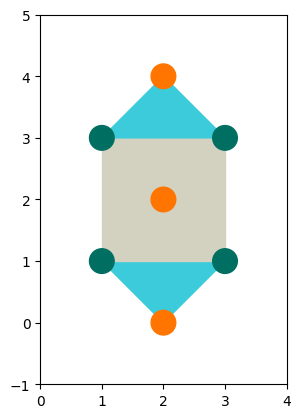

In [3]:
from deltakit.explorer import codes
# configure the rotated planar code
code = codes.RotatedPlanarCode(width=2, height=2)
code.draw_patch()

In [4]:
from deltakit.explorer.codes import css_code_memory_circuit
from deltakit.circuit.gates import PauliBasis

circuit = css_code_memory_circuit(code, num_rounds=1, logical_basis=PauliBasis.Z)

In [5]:
circuit

Circuit([
    GateLayer([
        RZ(Qubit(Coord2D(1, 1)))
        RZ(Qubit(Coord2D(3, 3)))
        RZ(Qubit(Coord2D(1, 3)))
        RZ(Qubit(Coord2D(3, 1)))
        RX(Qubit(Coord2D(2, 0)))
        RX(Qubit(Coord2D(2, 2)))
        RX(Qubit(Coord2D(2, 4)))
    ])
    GateLayer([
        I(Qubit(Coord2D(1, 1)))
        I(Qubit(Coord2D(1, 3)))
        I(Qubit(Coord2D(3, 1)))
        I(Qubit(Coord2D(3, 3)))
    ])
    GateLayer([
        CZ(control=Qubit(Coord2D(2, 0)), target=Qubit(Coord2D(1, 1)))
        CX(control=Qubit(Coord2D(2, 2)), target=Qubit(Coord2D(1, 3)))
    ])
    GateLayer([
        CZ(control=Qubit(Coord2D(2, 0)), target=Qubit(Coord2D(3, 1)))
        CX(control=Qubit(Coord2D(2, 2)), target=Qubit(Coord2D(1, 1)))
    ])
    GateLayer([
        CX(control=Qubit(Coord2D(2, 2)), target=Qubit(Coord2D(3, 3)))
        CZ(control=Qubit(Coord2D(2, 4)), target=Qubit(Coord2D(1, 3)))
    ])
    GateLayer([
        CX(control=Qubit(Coord2D(2, 2)), target=Qubit(Coord2D(3, 1)))
        CZ

In [7]:
stim_circuit = circuit.as_stim_circuit()

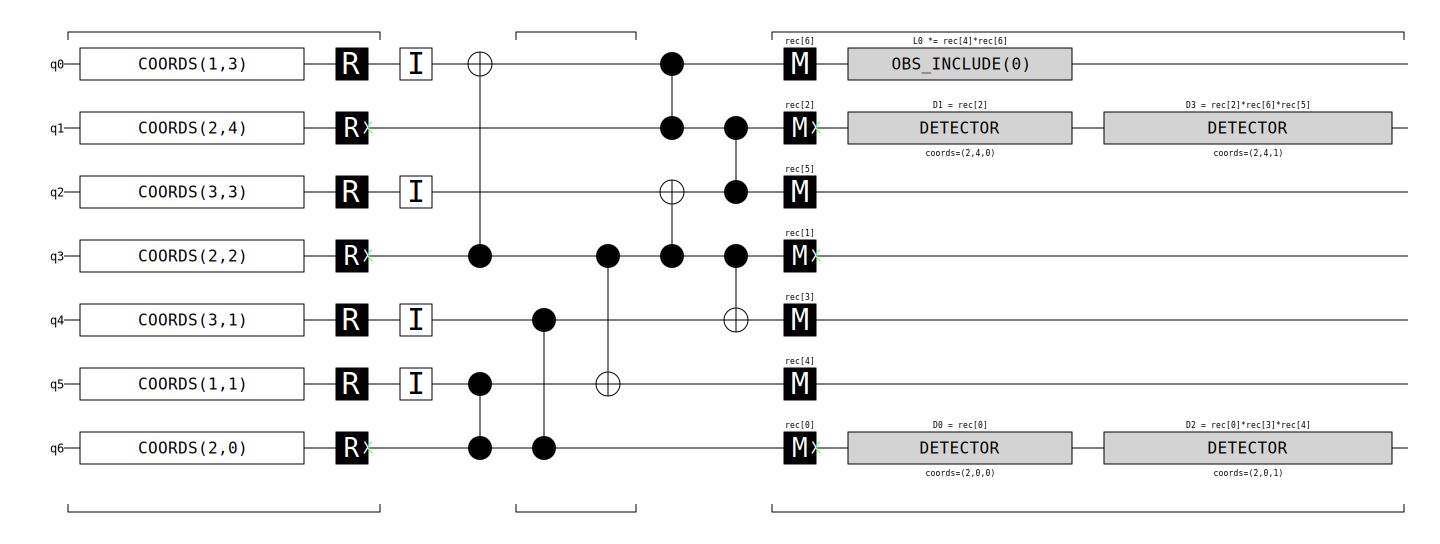

In [8]:
stim_circuit.diagram(type="timeline-svg")